In [78]:
from torchvision import datasets , transforms

In [79]:
!pip install torch torchvision


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
transforms.ToTensor()

ToTensor()

In [81]:
transform = transforms.ToTensor()

In [82]:
train_dataset = datasets.MNIST(root = "./data" , train = True , download= True , transform = transform )

In [83]:
print(len(train_dataset))

60000


In [84]:
image , label = train_dataset[45]

print(image.shape)
print(label)

torch.Size([1, 28, 28])
9


## Let's display the image

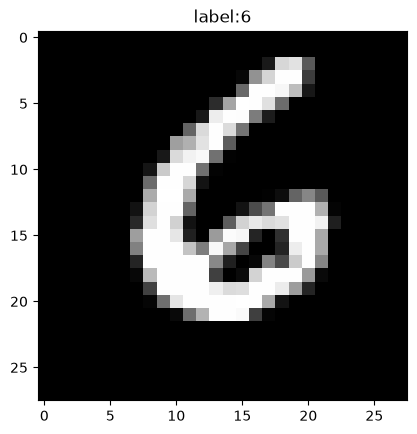

In [85]:
import matplotlib.pyplot as plt

image, label = train_dataset[90]

plt.imshow(image.squeeze(),cmap = "gray")
plt.title(f"label:{label}")
plt.show()

### We will use dataloader to get group of images in a batch 

In [86]:
from torch.utils.data import DataLoader

In [87]:
train_loader = DataLoader(train_dataset , batch_size= 64 , shuffle = True)

In [88]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [89]:
images = images.view(images.shape[0], -1)
print(images.shape)

torch.Size([64, 784])


### let's start building the model

In [90]:
import torch.nn as nn 

model = nn.Sequential(nn.Linear(784 , 128),
nn.ReLU() , 
nn.Linear(128,10))

In [91]:
images, labels = next(iter(train_loader))
images = images.view(images.shape[0], -1)

In [92]:
output = model(images)
print(output.shape)

torch.Size([64, 10])


In [93]:
print(output.shape)

torch.Size([64, 10])


In [94]:
print(output[0])

tensor([ 0.0668, -0.2502,  0.1215, -0.2829,  0.0742, -0.0599,  0.1075,  0.0541,
        -0.3357,  0.2179], grad_fn=<SelectBackward0>)


In [95]:
criterion = nn.CrossEntropyLoss()

loss = criterion(output , labels )



In [96]:
print(loss)

tensor(2.3004, grad_fn=<NllLossBackward0>)


In [97]:
epochs = 5

for epoch in range(epochs):

    for images , labels in train_loader:

        images = images.view(images.shape[0] , -1)

        optimizer.zero_grad()

        output = model(images)

        loss = criterion(output , labels )

        loss.backward()

        optimizer.step()

    print("Epoch:" , epoch +1 , "Loss:" , loss.item())

Epoch: 1 Loss: 2.282221794128418
Epoch: 2 Loss: 2.309974193572998
Epoch: 3 Loss: 2.266580820083618
Epoch: 4 Loss: 2.2882792949676514
Epoch: 5 Loss: 2.355105400085449


In [98]:
optimizer = optim.SGD(model.parameters(), lr=0.01)

NameError: name 'optim' is not defined

### it finds the average loss of all the batch , above it was finding the last batch loss

In [ ]:
epochs = 5

for epoch in range(epochs):

    total_loss = 0

    for images, labels in train_loader:

        images = images.view(images.shape[0], -1)

        optimizer.zero_grad()

        output = model(images)

        loss = criterion(output, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print("Epoch:", epoch + 1, "Average Loss:", average_loss)

Epoch: 1 Average Loss: 0.24980694679880955
Epoch: 2 Average Loss: 0.2404948276545066
Epoch: 3 Average Loss: 0.23229175638447183
Epoch: 4 Average Loss: 0.22425775013482774
Epoch: 5 Average Loss: 0.21683733265743707


checking the accuracy of training data

In [ ]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in train_loader:

        images = images.view(images.shape[0], -1)

        output = model(images)

        predictions = output.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

training_accuracy = correct / total * 100

print("Training Accuracy:", training_accuracy)



Training Accuracy: 93.97833333333332


In [ ]:
!pip install torch torchvision torchaudio


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Let's test the data

In [ ]:
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.view(images.shape[0], -1)

        output = model(images)

        predictions = output.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total * 100

print("Test Accuracy:", test_accuracy)

Test Accuracy: 93.77


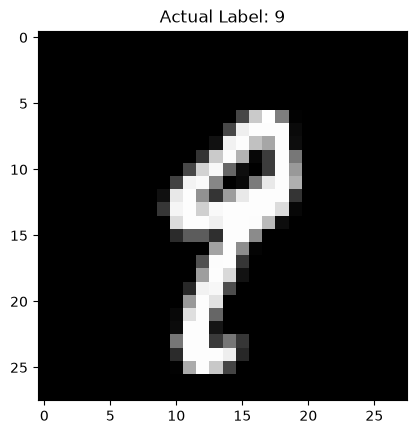

Actual: 9
Predicted: 9


In [ ]:
import matplotlib.pyplot as plt

image, label = test_dataset[78]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual Label: {label}")
plt.show()

input_image = image.view(1, -1)

with torch.no_grad():
    output = model(input_image)

prediction = output.argmax(dim=1)

print("Actual:", label)
print("Predicted:", prediction.item())

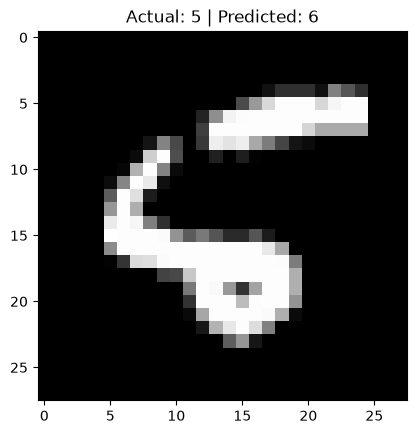

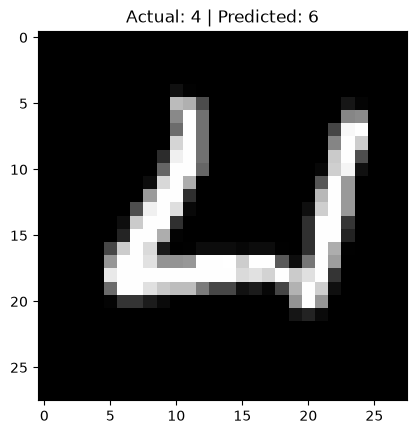

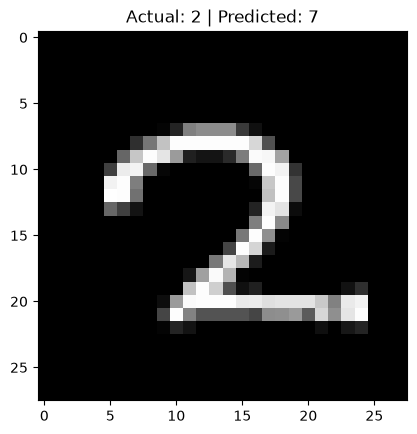

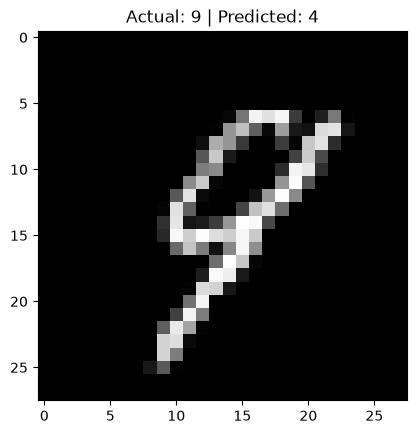

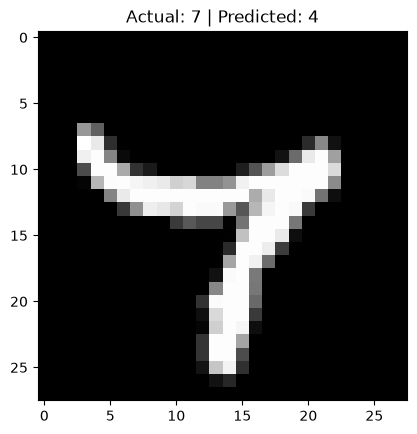

In [ ]:
import matplotlib.pyplot as plt

wrong = 0

for images, labels in test_loader:

    images_flat = images.view(images.shape[0], -1)

    with torch.no_grad():
        outputs = model(images_flat)

    predictions = outputs.argmax(dim=1)

    for i in range(len(labels)):

        if predictions[i] != labels[i]:

            plt.imshow(images[i].squeeze(), cmap="gray")
            plt.title(
                f"Actual: {labels[i].item()} | Predicted: {predictions[i].item()}"
            )
            plt.show()

            wrong += 1

            if wrong == 5:
                break

    if wrong == 5:
        break

To improve the accuracy now we will implement CNN


In [101]:
import torch.nn as nn


In [102]:
cnn_model = nn.Sequential(

    nn.Conv2d(1, 24, 3),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(24, 36, 3),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Flatten(),

    nn.Linear(900, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

In [103]:
criterion = nn.CrossEntropyLoss()

In [104]:
import torch

optimizer = torch.optim.SGD(cnn_model.parameters(), lr = 0.01)


In [105]:
cnn_model.parameters()

output = cnn_model(images)

In [115]:
epochs = 20

for epoch in range(epochs):

    total_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        output = cnn_model(images)

        loss = criterion(output, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print("Epoch:", epoch + 1, "Average Loss:", average_loss)

Epoch: 1 Average Loss: 0.04694034371486327
Epoch: 2 Average Loss: 0.0447828253631347
Epoch: 3 Average Loss: 0.043042765656011554
Epoch: 4 Average Loss: 0.04085934240676796
Epoch: 5 Average Loss: 0.038792859719716695
Epoch: 6 Average Loss: 0.03665983462050906
Epoch: 7 Average Loss: 0.03580401524906851
Epoch: 8 Average Loss: 0.03395741492056095
Epoch: 9 Average Loss: 0.03294171541173414
Epoch: 10 Average Loss: 0.03143649761327234
Epoch: 11 Average Loss: 0.030080078444359247
Epoch: 12 Average Loss: 0.02907916711857304
Epoch: 13 Average Loss: 0.027689394267173664
Epoch: 14 Average Loss: 0.026736363840809685
Epoch: 15 Average Loss: 0.02588469954480582
Epoch: 16 Average Loss: 0.024515445177408078
Epoch: 17 Average Loss: 0.023804630680349288
Epoch: 18 Average Loss: 0.022810211682978615
Epoch: 19 Average Loss: 0.022091789514078065
Epoch: 20 Average Loss: 0.02138805241561182


In [116]:
print(images.shape)

torch.Size([32, 1, 28, 28])


In [117]:
print(type(images))
print(images.shape)
print(cnn_model)

<class 'torch.Tensor'>
torch.Size([32, 1, 28, 28])
Sequential(
  (0): Conv2d(1, 24, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(24, 36, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=900, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)


In [118]:
x = images

for layer in cnn_model[:-1]:
    x = layer(x)

print(x.shape)

torch.Size([32, 128])


In [119]:
print(cnn_model)

Sequential(
  (0): Conv2d(1, 24, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(24, 36, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=900, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)


In [120]:
images, labels = next(iter(train_loader))

output = cnn_model(images)

print(output.shape)

torch.Size([64, 10])


we had trained our model let's test it

In [121]:
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [122]:
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [123]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        output = cnn_model(images)

        predictions = output.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

test_accuracy = correct / total * 100

print("CNN Test Accuracy:", test_accuracy)

CNN Test Accuracy: 98.77


cnn wrong predictions 

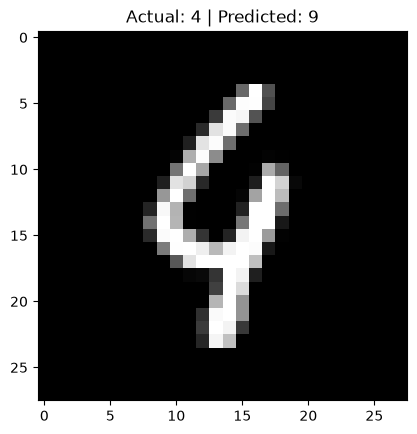

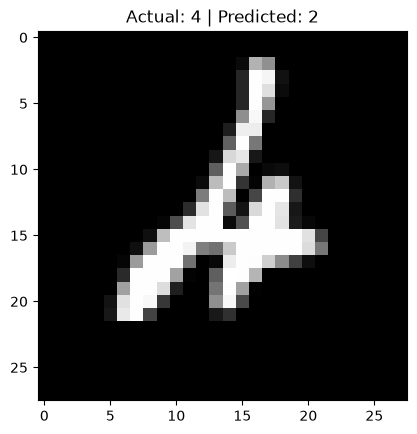

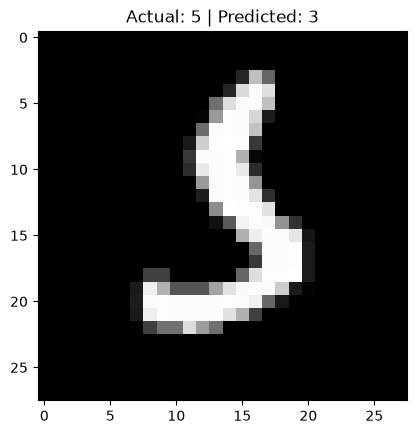

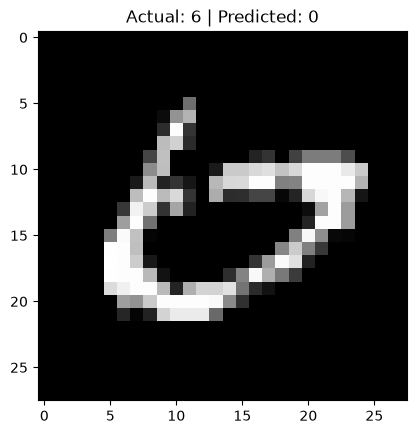

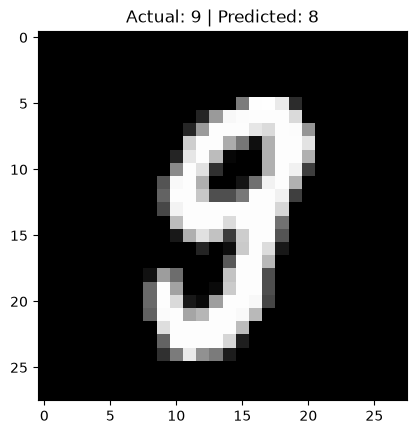

In [124]:
import matplotlib.pyplot as plt

wrong = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = cnn_model(images)
        predictions = outputs.argmax(dim=1)

        for i in range(len(labels)):

            if predictions[i] != labels[i]:

                plt.imshow(images[i].squeeze(), cmap="gray")
                plt.title(
                    f"Actual: {labels[i].item()} | Predicted: {predictions[i].item()}"
                )
                plt.show()

                wrong += 1

                if wrong == 5:
                    break

        if wrong == 5:
            break